In [1]:
import torch
import numpy as np
import random

# Wedge Product

In [2]:
max_action = 10
dim = 4
A = np.random.rand(max_action, dim)
print(A.shape)

(10, 4)


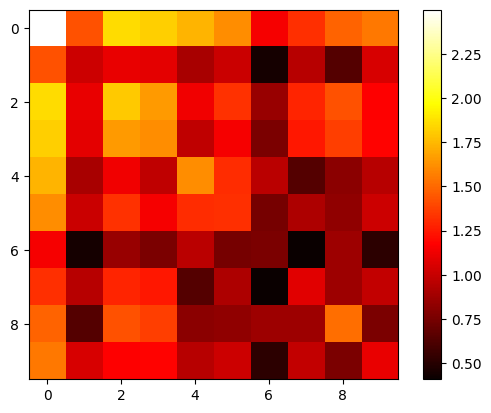

In [3]:
#plot the dot product
import matplotlib.pyplot as plt
plt.imshow(A.dot(A.T), cmap='hot',)
plt.colorbar()
#invert x axis
# plt.gca().invert_yaxis()
plt.show()

In [26]:
def wedge_product(u, v):
    wedge = np.outer(u, v) - np.outer(v, u)
    dim = u.shape[0]
    row_idx, col_idx = np.triu_indices(dim, k=1)
    bivector_components = wedge[row_idx, col_idx]
    return bivector_components

In [31]:
u = np.array([1, 2, 0, -1])
v = np.array([3, -1, 4, 2])
bivector = wedge_product(u, v)
print("Bivector Components:\n", bivector)

Bivector Components:
 [-7  4  5  8  3  4]


In [32]:
bivector = wedge_product(v, u)
print("Bivector Components:\n", bivector)

Bivector Components:
 [ 7 -4 -5 -8 -3 -4]


In [58]:
u = np.array([1,0, 0, 0])
v = np.array([0, -1, 0, 0])
bivector = wedge_product(u, v)
print("Bivector Components:\n", bivector)
print((bivector**2).sum())

Bivector Components:
 [-1  0  0  0  0  0]
1


In [57]:
#two orthagonal unit vectors should give the same bivector
u = np.random.rand(4)
u = u / np.linalg.norm(u)

#orthogonal to u
v = np.random.rand(4)
v = v - (v @ u) * u
v = v / np.linalg.norm(v)

bivector = wedge_product(u, v)
print("Bivector Components:\n", bivector)
print(bivector.sum())
print((bivector**2).sum())

Bivector Components:
 [-0.37359677 -0.07166519  0.58772614  0.23758434  0.48526193  0.46684267]
1.3321531051016975
1.0000000000000002


In [59]:
def pairwise_wedge(U, V):
    import numpy as np


    n, d = U.shape[0], U.shape[1]

    # Reshape for broadcasting: 
    # U becomes shape (10, 1, 4)
    # V becomes shape (1, 10, 4)
    U_expanded = U[:, np.newaxis, :]
    V_expanded = V[np.newaxis, :, :]

    # Compute the generalized outer product grid: shape (10, 10, 4, 4)
    # entry [i, j] gives the full matrix outer product of U[i] and V[j]
    outer_UV = U_expanded[:, :, :, np.newaxis] * V_expanded[:, :, np.newaxis, :]
    outer_VU = V_expanded[:, :, :, np.newaxis] * U_expanded[:, :, np.newaxis, :]

    # Subtract to get the antisymmetric wedge product matrix grid
    pairwise_wedge_matrices = outer_UV - outer_VU
    # Get the upper triangle indices for a d x d matrix
    row_idx, col_idx = np.triu_indices(d, k=1)

    # Slice the last two dimensions to extract the independent planes
    pairwise_bivectors = pairwise_wedge_matrices[:, :, row_idx, col_idx]

    print("Unique Component Grid Shape:", pairwise_bivectors.shape)
    # Output: (10, 10, 6)

    
    return pairwise_bivectors

In [ ]:
U = np.random.rand(max_action, dim)
V = np.random.rand(max_action, dim)

#normal each vector to unit length
U = U / np.linalg.norm(U, axis=1, keepdims=True)
V = V / np.linalg.norm(V, axis=1, keepdims=True)


array([[0.46787959, 0.47031918, 0.69626082, 0.274061  ],
       [0.32950489, 0.62105452, 0.60190833, 0.37871383],
       [0.23390394, 0.08524537, 0.0921043 , 0.96412601],
       [0.69747306, 0.47961972, 0.26035832, 0.46444569],
       [0.06428561, 0.21322963, 0.74492071, 0.62888284],
       [0.59137976, 0.29202688, 0.49858758, 0.56249507],
       [0.31612925, 0.85095766, 0.07108276, 0.41337707],
       [0.03984449, 0.62467869, 0.48765523, 0.60858963],
       [0.62846252, 0.54355905, 0.55638918, 0.00308317],
       [0.58171715, 0.11575957, 0.58552716, 0.55259644]])

In [44]:
pairwise_bivectors = pairwise_wedge(U, U)
pairwise_bivectors.shape

Unique Component Grid Shape: (10, 10, 6)


(10, 10, 6)

In [45]:
print(pairwise_bivectors[0, 1 , :])
print(pairwise_bivectors[1, 0 , :])

[ 0.13560627  0.05219928  0.08688804 -0.1493269   0.00790956  0.09872401]
[-0.13560627 -0.05219928 -0.08688804  0.1493269  -0.00790956 -0.09872401]


Sum of Unique Components Shape: (10, 10)


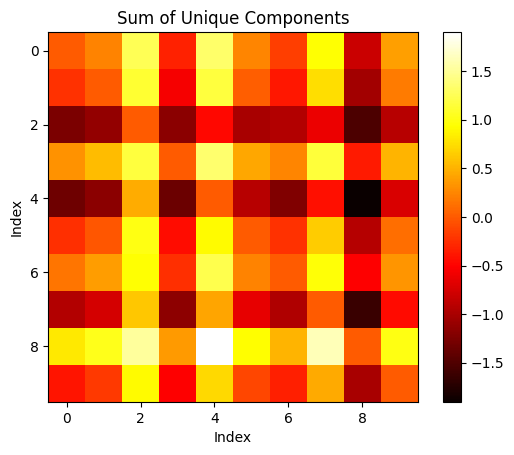

In [46]:
out = pairwise_bivectors.sum(axis=-1)
print("Sum of Unique Components Shape:", out.shape)


#Plot heatmap of out 
import matplotlib.pyplot as plt

plt.imshow(out, cmap='hot')
plt.colorbar()
plt.title('Sum of Unique Components')
plt.xlabel('Index')
plt.ylabel('Index')
plt.show()


In [25]:
out[0, 0], out[-1, -1] 

(np.float64(0.9718080805865021), np.float64(2.0324525175646317))

In [36]:
pairwise_bivectors[0, 0 , :]

array([ 0.77395053,  0.48435013,  0.6986629 , -0.28045134, -0.58916531,
       -0.11553884])

In [48]:
out.max(), out.min()

(np.float64(1.901535972134563), np.float64(-1.901535972134563))

In [37]:
print(pairwise_bivectors[0, 1 , :])
print(pairwise_bivectors[1, 0 , :])

[ 0.57370349  0.02113284  0.72138299 -0.25588209 -0.40782642  0.30672719]
[ 0.27392967  0.18232188  0.25138974  0.15621233 -0.11219768 -0.21803505]


## Action decoder

In [ ]:
def calculate_angle(from_planet_id, to_planet_id, num_ships):
    pass

def decode_action(action_np: np.ndarray, planets: np.ndarray, omega: float) -> list:
    """
    Convert policy output to a list of kaggle orbit_wars moves.

    Parameters
    ----------
    action_np : [n, 4]  (unit normalized)
    planets   : [n, 7]  swapped planet array [id, owner, x, y, radius, ships, production]
                Already in player-0 perspective (owner==0 means our planet).
    omega     : float — angular velocity (unused in decoding, kept for API symmetry)

    Returns
    -------
    moves : list of [planet_id (int), angle_radians (float), num_ships (int)]
    """

    pairwise_bivectors = pairwise_wedge(action_np, action_np)
    out = pairwise_bivectors.sum(axis=-1)
    out = np.tanh(out)  # nonlinearity to keep values in a reasonable range

    #masking out to only consider moves from our planets
    owner_mask = (planets[:, 1] == 0)
    # out = out * owner_mask[:, np.newaxis]


    moves = []
    n_planets = min(planets.shape[0], action_np.shape[0])

    for i in range(n_planets):
        if not owner_mask[i]:
            continue
        
        if out[i].max() <= 0.0:
            continue

        idx = np.argmax(out[i])

        from_planet_id = int(planets[i, 0])
        to_planet_id = planets[idx, 0]
        frac = out[i, idx]
        ships     = int(planets[i, 5])
        num_ships = int(frac * ships)
        if num_ships <= 0:
            continue

        angle_rad = calculate_angle(from_planet_id, to_planet_id, num_ships)
        moves.append([from_planet_id, angle_rad, num_ships])

    return moves

# Env test

In [47]:
from env.orbit_wars import OrbitWarsEnv, pairwise_wedge, decode_action, _obs_to_arrays, _swap_perspective, _EMPTY_FLEETS

env = OrbitWarsEnv(opponent="random", player_id=0)

state, _ = env.reset()
print("Initial state shape:", state.shape)
# print(state)


Initial state shape: (140, 14)


In [48]:
# planets - [id, owner, x, y, radius, ships, production]
# out - [owner[4], radius, ships, production, moving/static, angular_velocity, comet, is_planet, x, y, time_step]
# fleets - [id, owner, x, y, angle, from_planet_id, ships] or empty array
# out - [owner[4], angle, ships, speed, dummy[3], is_planet, x, y, time_step] or empty array

# state

In [51]:
#idx of opponent planets
owned_planet_masks = state[:, 0] == 1
opponent_planet_masks = state[:, 1] == 1

owned_planet_idx = np.where(owned_planet_masks == True)[0]
opponent_planet_idx = np.where(opponent_planet_masks == True)[0]

print(owned_planet_idx)
print(opponent_planet_idx)

[ 8 17 19 29]
[  0   1   2   3   4   5   6   7   9  10  11  12  13  14  15  16  18  20
  21  22  23  24  25  26  27  28  30  31  32  33  34  35  40  41  42  43
  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61
  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97
  98  99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115
 116]


In [42]:
state[owned_planet_masks]

array([[1.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
        1.0000000e+00, 1.0000000e+01, 1.0000000e+00, 1.0000000e+00,
        4.9872540e-02, 0.0000000e+00, 0.0000000e+00, 6.8117485e+01,
        6.7637154e+01, 0.0000000e+00]], dtype=float32)

In [6]:
action_np = np.zeros((env.MAX_PLANETS, 4))

self_planet= np.array([[1, 0, 0, 0]] )
target_planet = np.array([[0, 0, 1, 0]] )

action_np[12] = self_planet
action_np[13] = target_planet

out = pairwise_wedge(action_np, action_np)
out = out.sum(axis=-1)
print(out)
print(out.sum(axis=-1))
# action_np[12] = self_planet
# action_np[0] = target_planet

# state, reward, terminated, truncated, info = env.step(action_np)

NameError: name 'pairwise_wedge' is not defined

In [44]:
planets_np, fleets_np, omega, _, comet_ids_np = _obs_to_arrays(env._current_obs)
s_planets, _ = _swap_perspective(
    planets_np, _EMPTY_FLEETS.copy(), env.player_id
)
moves = decode_action(action_np, s_planets, 0.1)
print(moves)

#planet id =8 , but it gives id as 1 


[]


In [16]:
moves = [[]]

In [19]:
raw_obs, _kaggle_reward, done, info = env._trainer.step(moves)
raw_obs

{'remainingOverageTime': 60,
 'step': 3,
 'planets': [[0, 0, 89.24559181489391, 98.97616743923322, 1.0, 6, 1],
  [1, -1, 1.0238325607667775, 89.24559181489391, 1.0, 16, 1],
  [2, -1, 98.97616743923322, 10.754408185106087, 1.0, 16, 1],
  [3, 1, 10.754408185106087, 1.0238325607667775, 1.0, 13, 1],
  [4, -1, 97.66143513523403, 63.913552961521376, 1.0, 71, 1],
  [5, -1, 36.086447038478624, 97.66143513523403, 1.0, 71, 1],
  [6, -1, 63.913552961521376, 2.3385648647659707, 1.0, 71, 1],
  [7, -1, 2.3385648647659707, 36.086447038478624, 1.0, 71, 1],
  [8, -1, 68.15133740156716, 97.91813717435465, 1.6931471805599454, 33, 2],
  [9, -1, 2.081862825645345, 68.15133740156716, 1.6931471805599454, 33, 2],
  [10, -1, 97.91813717435465, 31.84866259843284, 1.6931471805599454, 33, 2],
  [11, -1, 31.84866259843284, 2.081862825645345, 1.6931471805599454, 33, 2],
  [12, -1, 75.72708842929644, 75.79829098354723, 2.6094379124341005, 14, 5],
  [13, -1, 24.201709016452757, 75.72708842929643, 2.6094379124341005, 

## Simulation

In [2]:
from env.orbit_wars import OrbitWarsEnv, RewardScheme1, RewardScheme2, RewardScheme3, RewardScheme4


env = OrbitWarsEnv(opponent="random", player_id=0, reward_scheme=[RewardScheme4( ship_scale = 0.5, planet_scale =1, win_bonus = 1000.0)])

state, _ = env.reset()
print("Initial state shape:", state.shape)
# print(state)


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment

In [3]:
#idx of opponent planets
owned_planet_masks = state[:, 0] == 1
opponent_planet_masks = state[:, 1] == 1

owned_planet_idx = np.where(owned_planet_masks == True)[0]
opponent_planet_idx = np.where(opponent_planet_masks == True)[0]

self_planet= np.array([[1, 0, 0, 0]] )
target_planet = np.array([[0, 0, 1, 0]] )

print(owned_planet_idx)
print(opponent_planet_idx)

[12]
[15]


In [4]:
#run for n steps without any actions 
from tqdm import tqdm

zero_action = np.zeros((env.MAX_PLANETS, 4))
n_step = 499

action_step = 100
reward_list = []
won_list = []

html_path = 'orbit_wars_test.html'
for i in tqdm(range(n_step)):
    action_np = zero_action.copy()
    if i % action_step == 0:
        from_idx = np.random.choice(owned_planet_idx)
        action_np[from_idx] = self_planet

        # action_np[12] = self_planet
        #sample anything not owned by us or opponent 
        sample_idx = list(set(range(env.MAX_PLANETS)) - set(owned_planet_idx) - set(opponent_planet_idx))
        to_idx = np.random.choice(sample_idx)
        # idx = 13
        # print(f"Step {i}: from index {from_idx} to index {to_idx}")
        action_np[to_idx] = target_planet

    state, reward, terminated, truncated, won = env.step(action_np)
    reward_list.append(reward)
    won_list.append(won)
    if terminated or truncated:
        print(f"Episode ended at step {i} with reward {reward}")
        break

    owned_planet_masks = state[:40, 0] == 1
    owned_planet_idx = np.where(owned_planet_masks == True)[0]

env.render(mode='html', html_path=html_path)



100%|█████████▉| 498/499 [00:02<00:00, 170.11it/s]


Episode ended at step 498 with reward 2252.0
Replay saved : orbit_wars_test.html


Total reward 304165.5


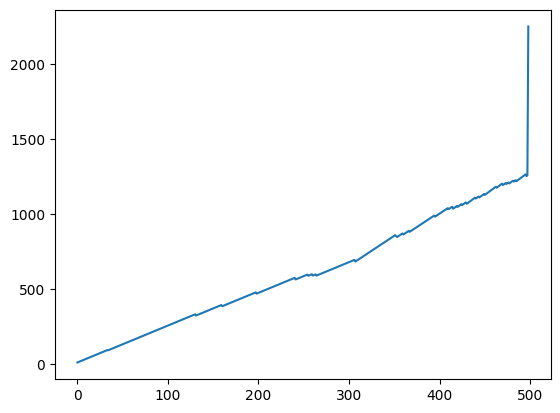

In [6]:
import matplotlib.pyplot as plt

plt.plot(reward_list)
print(f"Total reward {np.array(reward_list).sum()}")

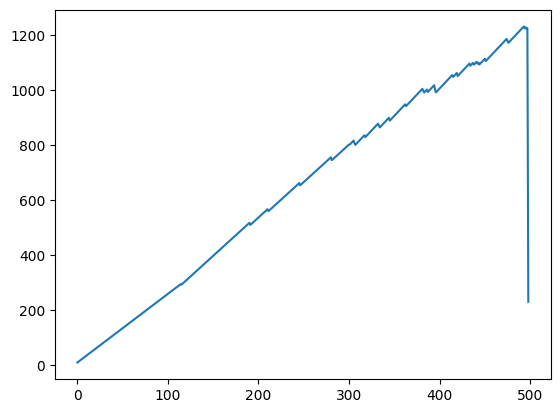

In [13]:
import matplotlib.pyplot as plt

plt.plot(reward_list)